In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import h5py
from torch.utils.data import Dataset
import sys
sys.path.append('../../src/')
from trainer_ddp import main

# if __name__ == "__main__":
#     # import argparse
#     # parser = argparse.ArgumentParser(description='simple distributed training job')
#     # parser.add_argument('total_epochs', type=int, help='Total epochs to train the model')
#     # parser.add_argument('save_every', type=int, help='How often to save a snapshot')
#     # parser.add_argument('--batch_size', default=32, type=int, help='Input batch size on each device (default: 32)')
#     # args = parser.parse_args()
    
#     world_size = torch.cuda.device_count()
#     save_every = 10
#     total_epochs = 50
#     batch_size = 64
#     mp.spawn(main, args=(world_size, save_every, total_epochs, batch_size), nprocs=world_size)
        
def split_train_valid(dataset, train_ratio, seed=42):
    imagenet_size = len(dataset)
    train_size = int(train_ratio * imagenet_size)
    valid_size = imagenet_size - train_size
    train_ds, valid_ds = torch.utils.data.random_split(dataset, [train_size, valid_size], 
                                                       generator=torch.Generator().manual_seed(seed))
    return train_ds, valid_ds

def list_to_dict(lst):
    dictionary = {}
    for index, item in enumerate(lst):
        dictionary[index] = item
    return dictionary

class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
            
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels

In [2]:
import torch
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

world_size = torch.cuda.device_count()
total_epochs = 3
batch_size = 128
lr = 1e-3 
tracking = False
mp.spawn(main, args=(world_size, total_epochs, batch_size, lr, tracking), nprocs=world_size)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 

Epoch 0: train Loss: 0.3071, train Accuracy: 0.58%
Epoch 0: train Loss: 0.3063, train Accuracy: 0.62%
Epoch 0: train Loss: 0.3068, train Accuracy: 0.58%


 96%|█████████▌| 76/79 [00:17<00:00,  5.23it/s]

Epoch 0: train Loss: 0.3069, train Accuracy: 0.59%


100%|██████████| 79/79 [00:17<00:00,  5.95it/s]

...

Epoch 2: train Loss: 0.2924, train Accuracy: 0.61%


 97%|█████████▋| 77/79 [00:16<00:00,  5.25it/s]

Epoch 2: train Loss: 0.2928, train Accuracy: 0.67%
Epoch 2: train Loss: 0.2916, train Accuracy: 0.64%


100%|██████████| 79/79 [00:16<00:00,  4.66it/s]


Epoch 2: train Loss: 0.2927, train Accuracy: 0.60%


In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../src/')
from build_model import resnet50_yichen
from trainer import Trainer
from dataset_functions import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from visualization_functions import show_images

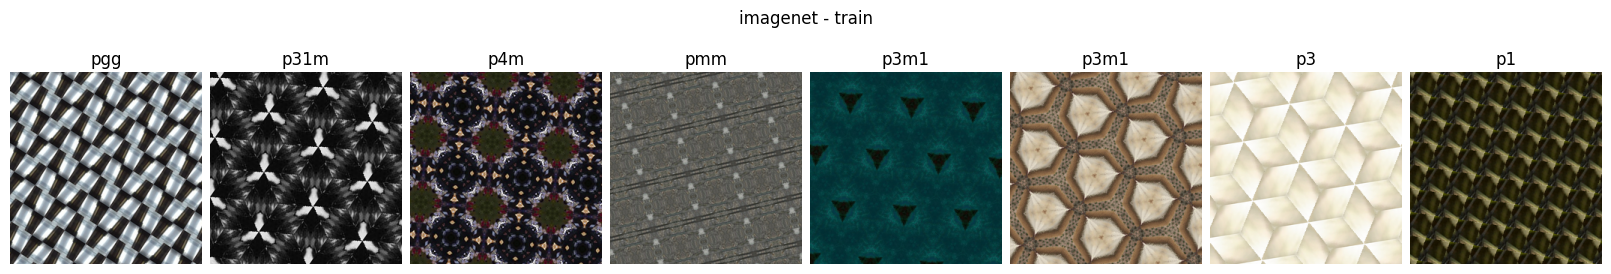

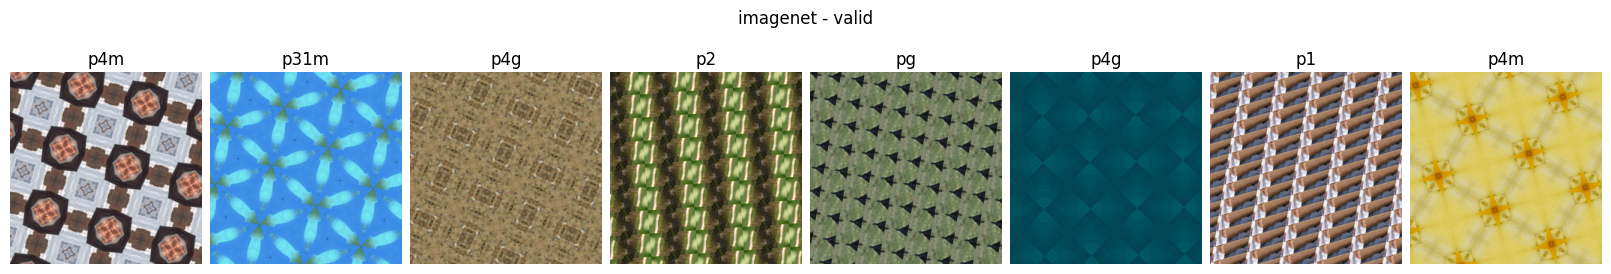

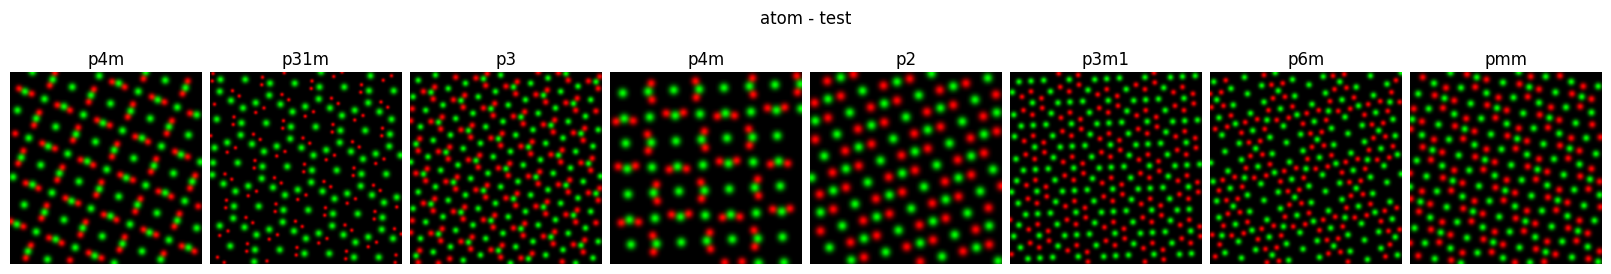

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet
valid_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=False, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test')

In [3]:
model = resnet50_yichen(in_channels=3, n_classes=17)
print(model)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets',
    'model': 'fpn_resnet50_yichen',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'test'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='benchmark', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
lr = 1e-3
max_epochs = 2

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=max_epochs, max_lr=lr, steps_per_epoch=len(train_dl))
trainer = Trainer(model, train_dl, valid_dl, test_dl, loss_func, optimizer, scheduler, gpu_id=device, save_every=10, model_path=None)

In [6]:
trainer.train(max_epochs=max_epochs, tracking=True)

Epoch: 1/2:


100%|██████████| 391/391 [02:23<00:00,  2.73it/s]

train Loss: 2.9425, train Accuracy: 6.42%



100%|██████████| 391/391 [00:55<00:00,  7.07it/s]

valid Loss: 2.7969, valid Accuracy: 9.29%


...

train Loss: 2.4174, train Accuracy: 18.37%



100%|██████████| 391/391 [00:54<00:00,  7.18it/s]

valid Loss: 1.9853, valid Accuracy: 32.02%



100%|██████████| 391/391 [00:53<00:00,  7.27it/s]

test Loss: 3.1064, test Accuracy: 11.94%


In [7]:
from train_functions import train_epochs

In [8]:
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
lr = 1e-3
max_epochs = 2

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=max_epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=max_epochs, 
                       scheduler=scheduler, tracking=True)

Epoch: 1/2


  0%|          | 0/391 [00:00<?, ?it/s]

100%|██████████| 391/391 [02:15<00:00,  2.89it/s]


Training: Loss: 1.4943, Accuracy: 45.0860%, Time: 2.2574mins


100%|██████████| 391/391 [00:53<00:00,  7.25it/s]


...

Training: Loss: 0.7371, Accuracy: 71.8760%, Time: 2.2333mins


100%|██████████| 391/391 [00:54<00:00,  7.23it/s]


Validation : Loss : 0.4987, Accuracy: 81.3800%, Time: 0.90mins


100%|██████████| 391/391 [00:54<00:00,  7.21it/s]

Validation : Loss : 3.8916, Accuracy: 29.0420%, Time: 0.90mins


(array([ 2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  2.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  2.,
         0.,  1.,  0.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  0.,  2.,  0.,
         0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         1.,  1.,  0.,  0.,  0.,  1.,  0.,  2.,  1.,  1.,  0.,  1.,  0.,
         0.,  1.,  0.,  1.,  0.,  1.,  2.,  0.,  0.,  2.,  0.,  0.,  1.,
         2.,  0.,  1.,  1.,  3.,  1.,  1.,  3.,  0.,  2.,  2.,  0.,  1.,
         2.,  3.,  1.,  1.,  0.,  3.,  1.,  1.,  0.,  3.,  2.,  1.,  2.,
         0.,  2.,  1.,  3.,  2.,  2.,  2.,  0.,  2.,  2.,  1.,  4.,  0.,
         1.,  1.,  3.,  3.,  2.,  6.,  2.,  3.,  1.

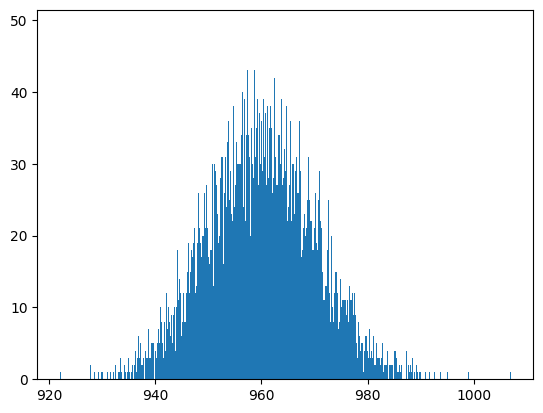

In [15]:
values =[]
for i in range(10000):
    values.append(np.random.normal(loc=960, scale=10))
plt.hist(values, bins=1000)

In [3]:
import torch
import torch.multiprocessing as mp
from multigpu import ddp_setup, load_train_objs, prepare_dataloader, destroy_process_group

In [4]:
def main(rank: int, world_size: int, save_every: int, total_epochs: int, batch_size: int):
    ddp_setup(rank, world_size)
    dataset, model, optimizer = load_train_objs()
    train_data = prepare_dataloader(dataset, batch_size)
    trainer = Trainer(model, train_data, optimizer, rank, save_every)
    trainer.train(total_epochs)
    destroy_process_group()

In [1]:
import torch
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import os
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from multigpu import main, MyTrainDataset
world_size = torch.cuda.device_count()
total_epochs = 50
model = torch.nn.Linear(20, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
mp.spawn(main, args=(world_size, total_epochs, model, optimizer), nprocs=world_size)

In [1]:
import torch
from torch.utils.data import Dataset

class MyTrainDataset(Dataset):
    def __init__(self, size):
        self.size = size
        self.data = [(torch.rand(20), torch.rand(1)) for _ in range(size)]

    def __len__(self):
        return self.size
    
    def __getitem__(self, index):
        return self.data[index]

In [5]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from datautils import MyTrainDataset

import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import os


def ddp_setup(rank, world_size):
    """
    Args:
        rank: Unique identifier of each process
        world_size: Total number of processes
    """
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)

class Trainer:
    def __init__(
        self,
        model: torch.nn.Module,
        train_data: DataLoader,
        optimizer: torch.optim.Optimizer,
        gpu_id: int,
        save_every: int,
    ) -> None:
        self.gpu_id = gpu_id
        self.model = model.to(gpu_id)
        self.train_data = train_data
        self.optimizer = optimizer
        self.save_every = save_every
        self.model = DDP(model, device_ids=[gpu_id])

    def _run_batch(self, source, targets):
        self.optimizer.zero_grad()
        output = self.model(source)
        loss = F.cross_entropy(output, targets)
        loss.backward()
        self.optimizer.step()

    def _run_epoch(self, epoch):
        b_sz = len(next(iter(self.train_data))[0])
        print(f"[GPU{self.gpu_id}] Epoch {epoch} | Batchsize: {b_sz} | Steps: {len(self.train_data)}")
        self.train_data.sampler.set_epoch(epoch)
        for source, targets in self.train_data:
            source = source.to(self.gpu_id)
            targets = targets.to(self.gpu_id)
            self._run_batch(source, targets)

    def _save_checkpoint(self, epoch):
        ckp = self.model.module.state_dict()
        PATH = "checkpoint.pt"
        torch.save(ckp, PATH)
        print(f"Epoch {epoch} | Training checkpoint saved at {PATH}")

    def train(self, max_epochs: int):
        for epoch in range(max_epochs):
            self._run_epoch(epoch)
            if self.gpu_id == 0 and epoch % self.save_every == 0:
                self._save_checkpoint(epoch)


def load_train_objs():
    train_set = MyTrainDataset(2048)  # load your dataset
    model = torch.nn.Linear(20, 1)  # load your model
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
    return train_set, model, optimizer


def prepare_dataloader(dataset: Dataset, batch_size: int):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        pin_memory=True,
        shuffle=False,
        sampler=DistributedSampler(dataset)
    )


def main(rank: int, world_size: int, save_every: int, total_epochs: int, batch_size: int):
    ddp_setup(rank, world_size)
    dataset, model, optimizer = load_train_objs()
    train_data = prepare_dataloader(dataset, batch_size)
    trainer = Trainer(model, train_data, optimizer, rank, save_every)
    trainer.train(total_epochs)
    destroy_process_group()
    
# if __name__ == "__main__":
#     import argparse
#     parser = argparse.ArgumentParser(description='simple distributed training job')
#     parser.add_argument('total_epochs', type=int, help='Total epochs to train the model')
#     parser.add_argument('save_every', type=int, help='How often to save a snapshot')
#     parser.add_argument('--batch_size', default=32, type=int, help='Input batch size on each device (default: 32)')
#     args = parser.parse_args()
    
#     world_size = torch.cuda.device_count()
#     mp.spawn(main, args=(world_size, args.save_every, args.total_epochs, args.batch_size), nprocs=world_size)

In [8]:
def spawn_main(rank, world_size, save_every, total_epochs, batch_size):
    main(rank, world_size, save_every, total_epochs, batch_size)
    
# Set your parameters
total_epochs = 50
save_every = 10
batch_size = 32
world_size = torch.cuda.device_count()

# Call mp.spawn
mp.spawn(spawn_main, 
         args=(world_size, save_every, total_epochs, batch_size), 
         nprocs=world_size, 
         join=True)


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'main' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'main' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/

ProcessExitedException: process 0 terminated with exit code 1

In [23]:
total_epochs = 50
save_every = 10
batch_size = 32

# Function to run in each process
def run(rank, world_size, save_every, total_epochs, batch_size):
    main(rank, world_size, save_every, total_epochs, batch_size)

# Start the multiprocessing
world_size = torch.cuda.device_count()
processes = []
for rank in range(world_size):
    p = mp.Process(target=run, args=(rank, world_size, save_every, total_epochs, batch_size))
    p.start()
    processes.append(p)

for p in processes:
    p.join()

[GPU1] Epoch 0 | Batchsize: 32 | Steps: 7[GPU5] Epoch 0 | Batchsize: 32 | Steps: 7[GPU4] Epoch 0 | Batchsize: 32 | Steps: 7[GPU0] Epoch 0 | Batchsize: 32 | Steps: 7[GPU7] Epoch 0 | Batchsize: 32 | Steps: 7[GPU2] Epoch 0 | Batchsize: 32 | Steps: 7





[GPU6] Epoch 0 | Batchsize: 32 | Steps: 7[GPU8] Epoch 0 | Batchsize: 32 | Steps: 7[GPU9] Epoch 0 | Batchsize: 32 | Steps: 7

[GPU3] Epoch 0 | Batchsize: 32 | Steps: 7

[GPU5] Epoch 0 | Batchsize: 32 | Steps: 7[GPU4] Epoch 0 | Batchsize: 32 | Steps: 7[GPU0] Epoch 0 | Batchsize: 32 | Steps: 7[GPU7] Epoch 0 | Batchsize: 32 | Steps: 7[GPU2] Epoch 0 | Batchsize: 32 | Steps: 7





[GPU6] Epoch 0 | Batchsize: 32 | Steps: 7[GPU8] Epoch 0 | Batchsize: 32 | Steps: 7[GPU9] Epoch 0 | Batchsize: 32 | Steps: 7

[GPU3] Epoch 0 | Batchsize: 32 | Steps: 7

[GPU5] Epoch 1 | Batchsize: 32 | Steps: 7[GPU7] Epoch 1 | Batchsize: 32 | Steps: 7[GPU9] Epoch 1 | Batchsize: 32 | Steps: 7[GPU4] Epoch 1 | Batchsize: 32 | Steps: 7[GPU1] Epoch 1 | Batchsize: 32 | Step